In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

os.makedirs("reports/figures", exist_ok=True)

df = pd.read_csv("data/processed/cleaned_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


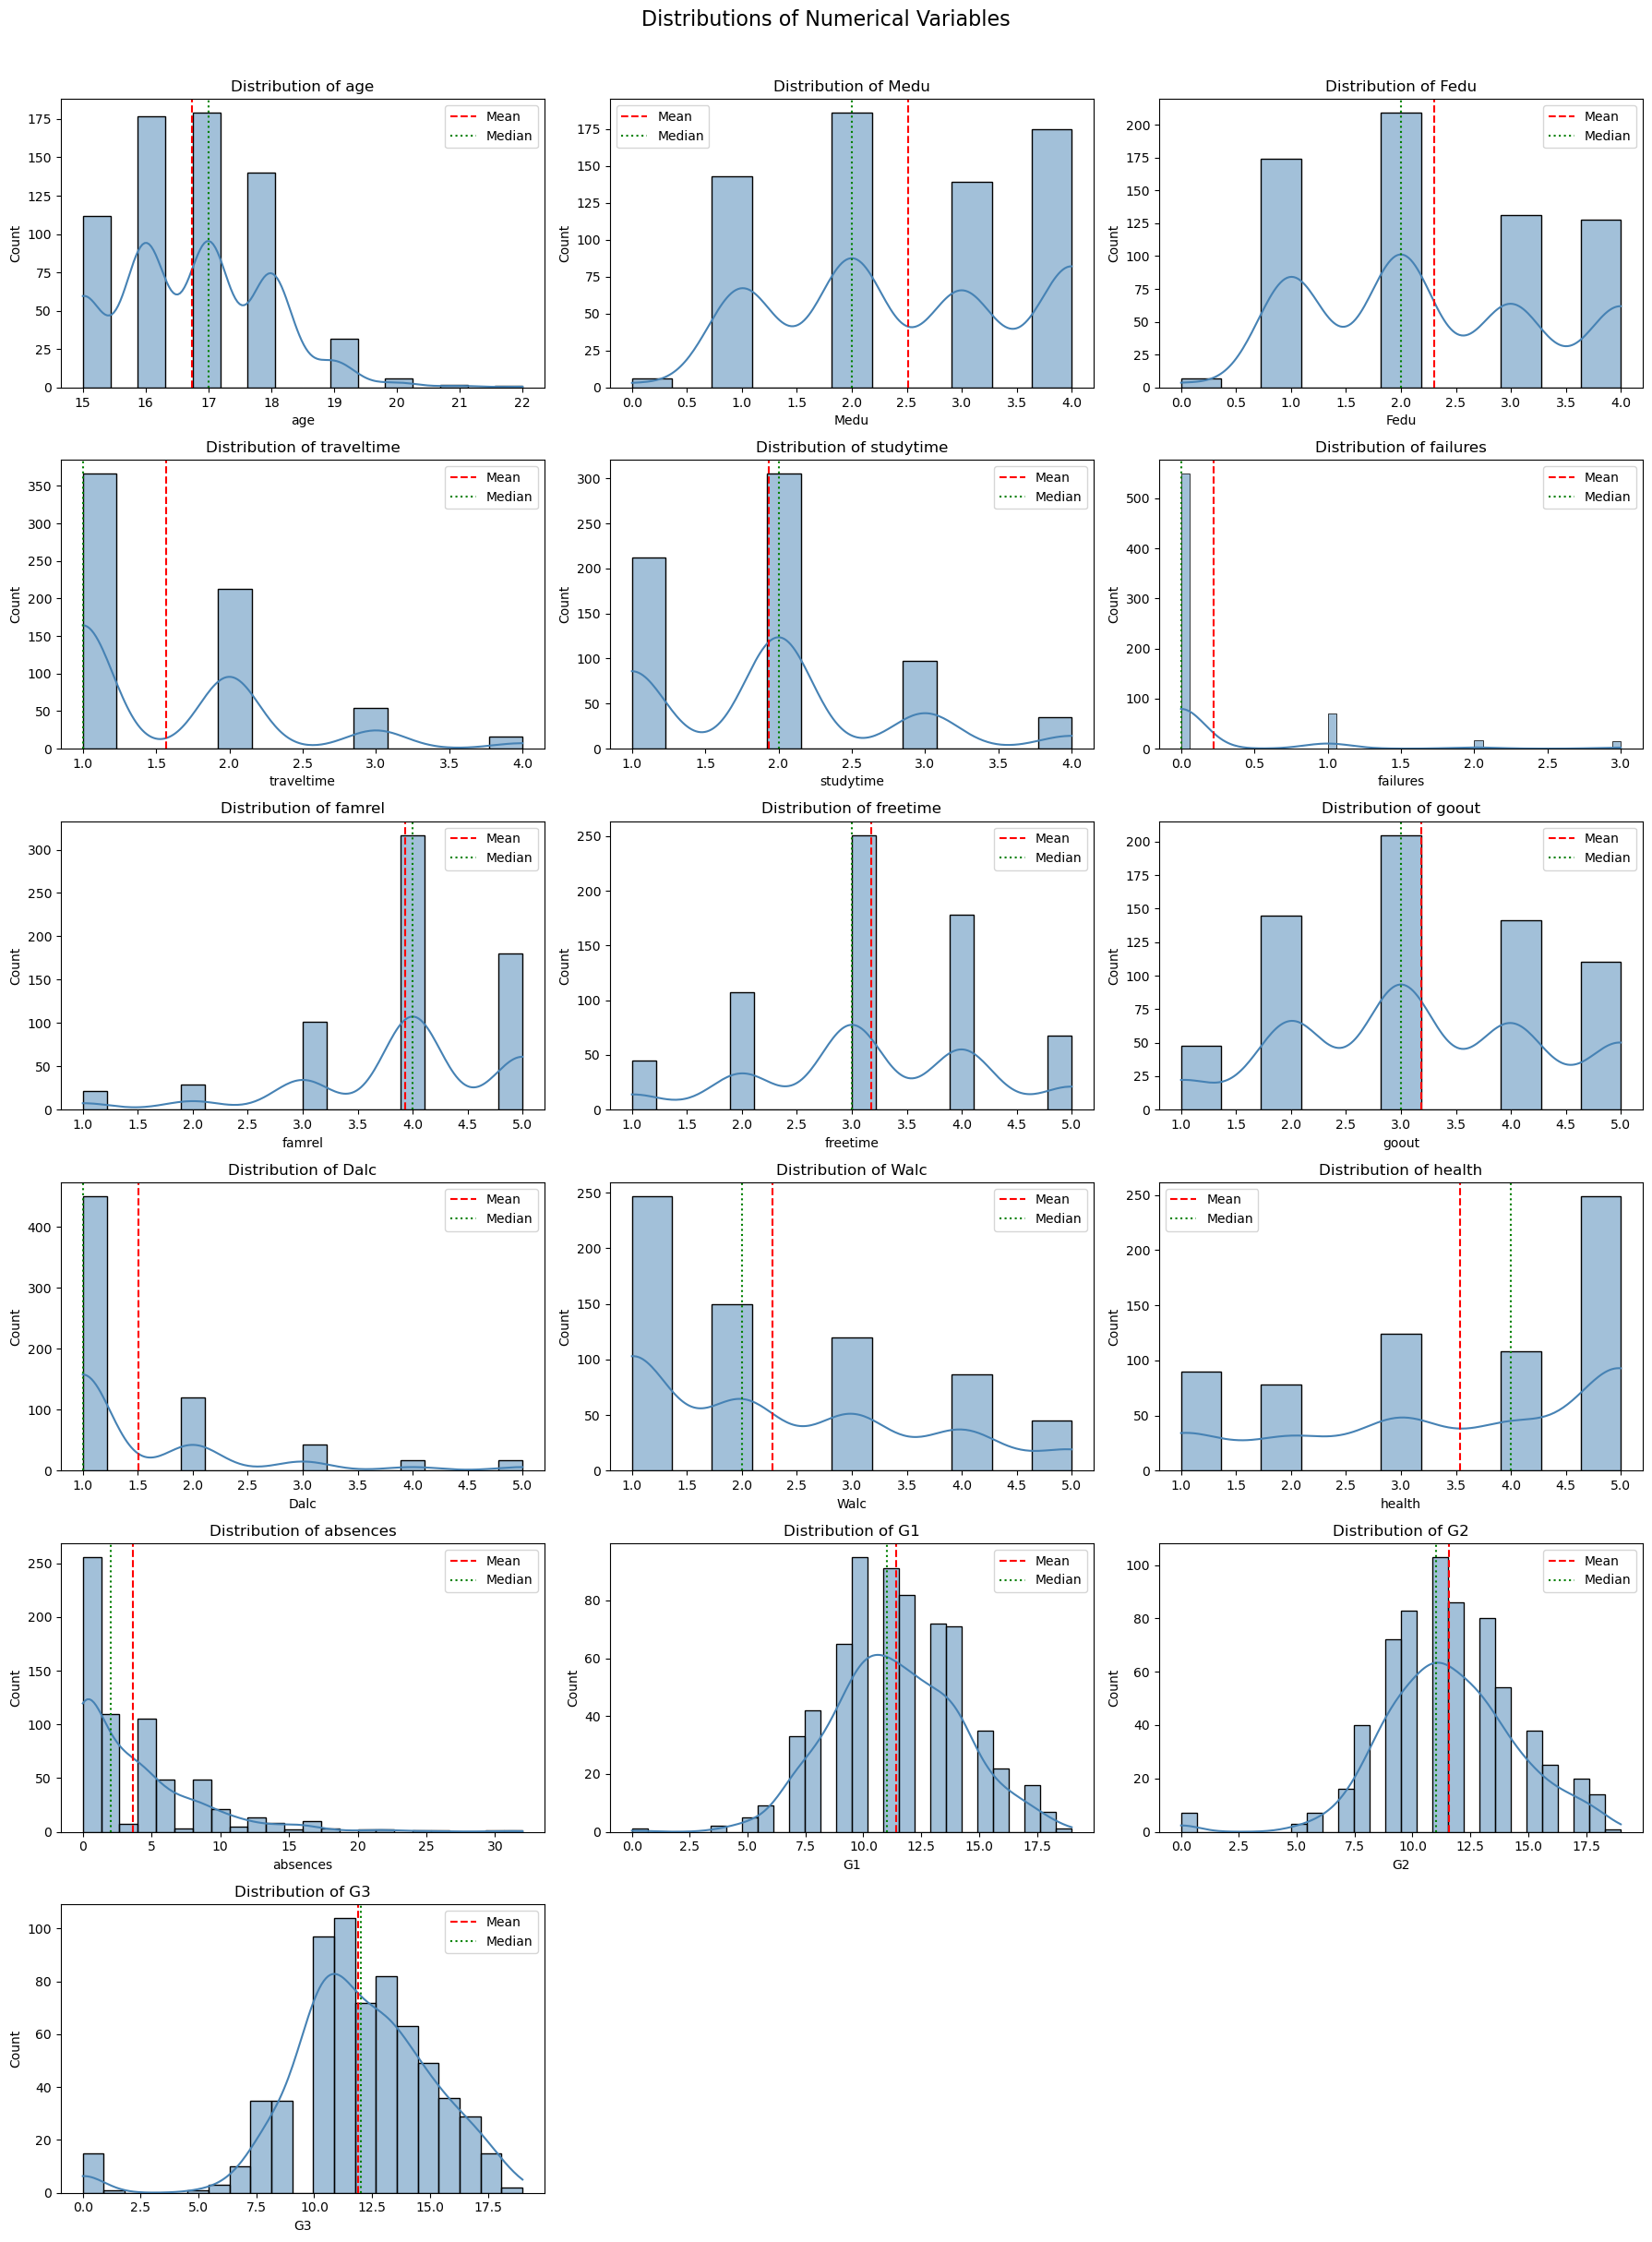

Saved: reports/figures/distribution_plots.png


In [2]:
numeric_cols = df.select_dtypes(include="number").columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    values = df[col].dropna()

    sns.histplot(values, kde=True, ax=ax, color="steelblue")
    ax.axvline(values.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(values.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.legend()

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of Numerical Variables", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("reports/figures/distribution_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/distribution_plots.png")

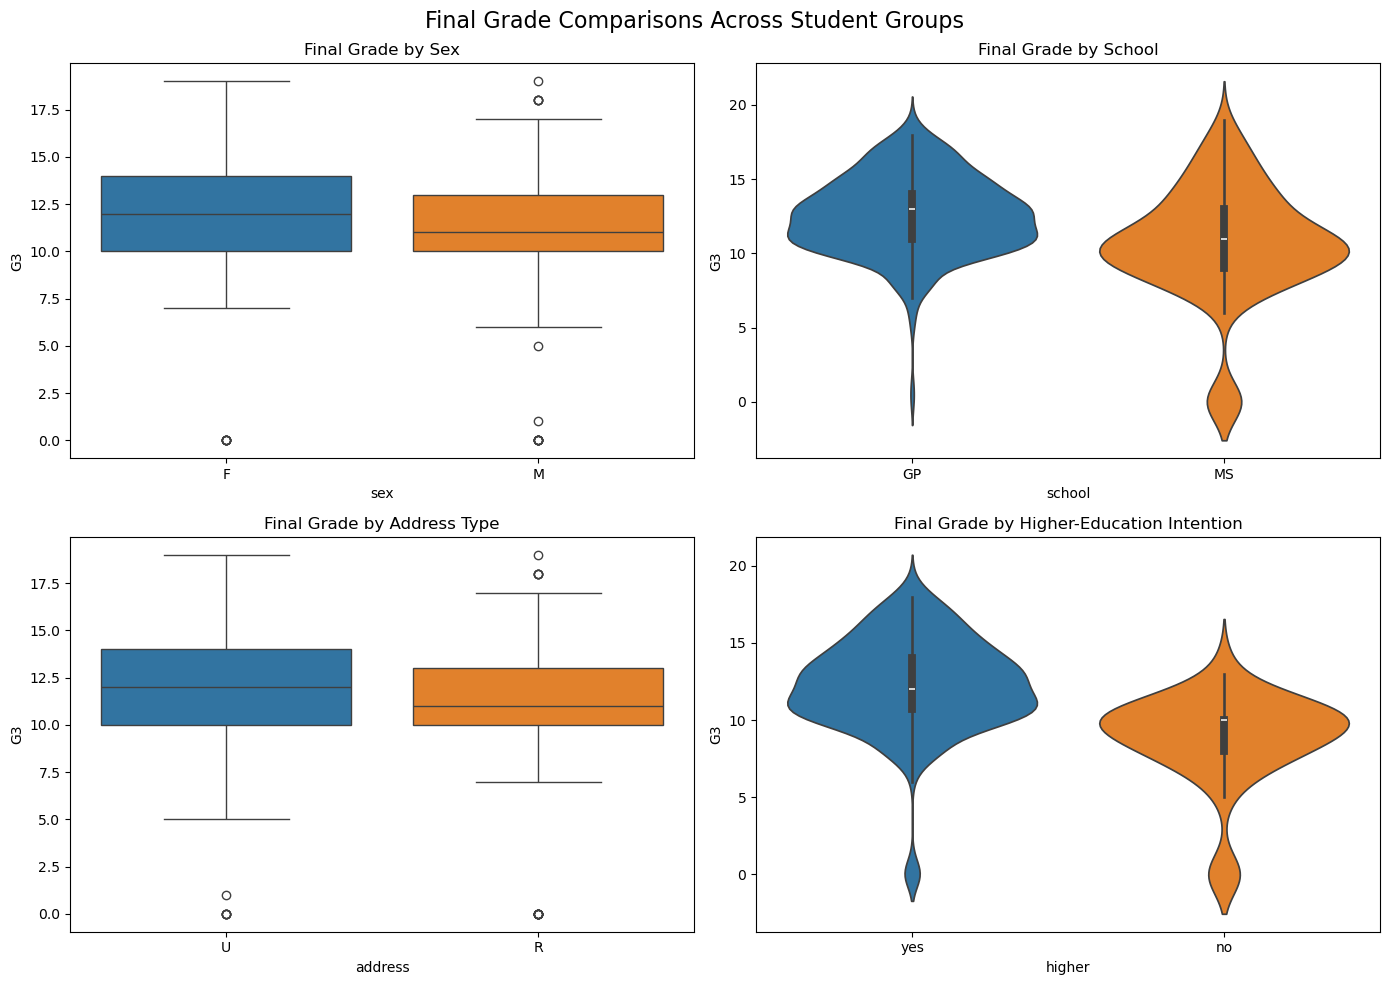

Saved: reports/figures/box_violin_plots.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="sex", y="G3", hue="sex", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Final Grade by Sex")

sns.violinplot(data=df, x="school", y="G3", hue="school", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Final Grade by School")

sns.boxplot(data=df, x="address", y="G3", hue="address", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Final Grade by Address Type")

sns.violinplot(data=df, x="higher", y="G3", hue="higher", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Final Grade by Higher-Education Intention")

fig.suptitle("Final Grade Comparisons Across Student Groups", fontsize=16)
plt.tight_layout()
plt.savefig("reports/figures/box_violin_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/box_violin_plots.png")

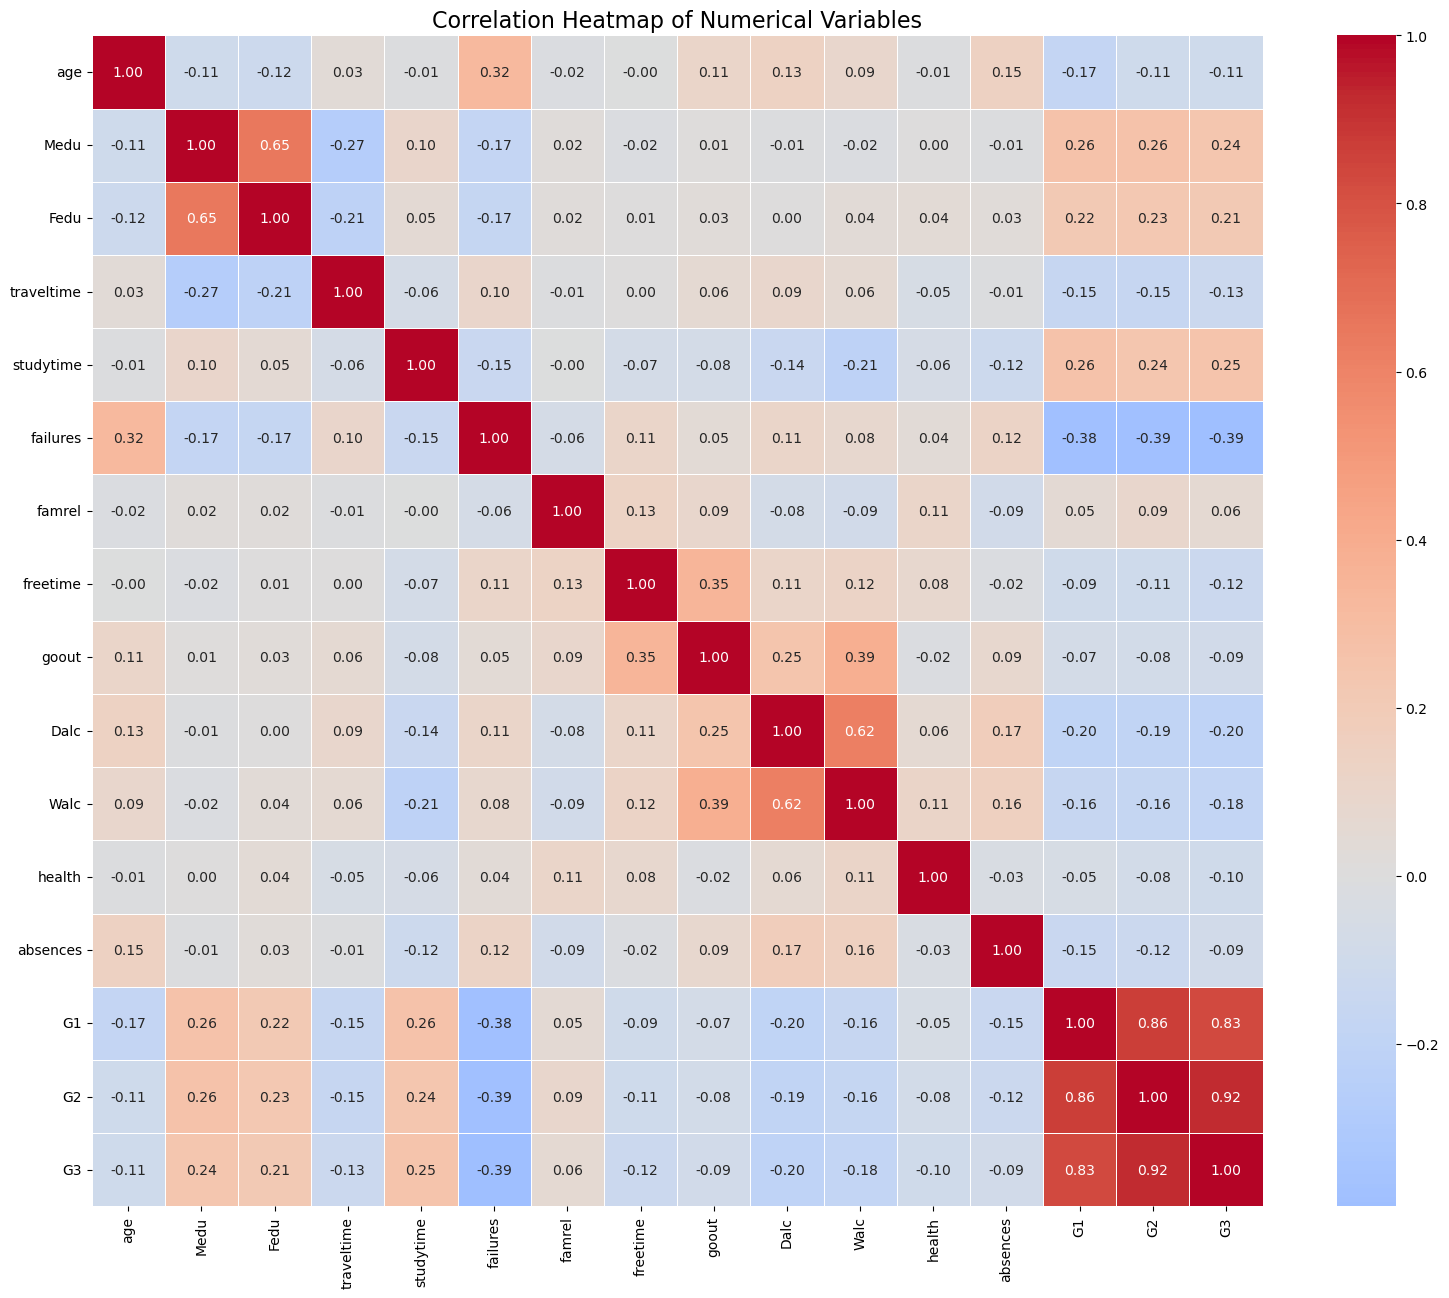

Saved: reports/figures/correlation_heatmap.png


In [4]:
correlation_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.savefig("reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/correlation_heatmap.png")

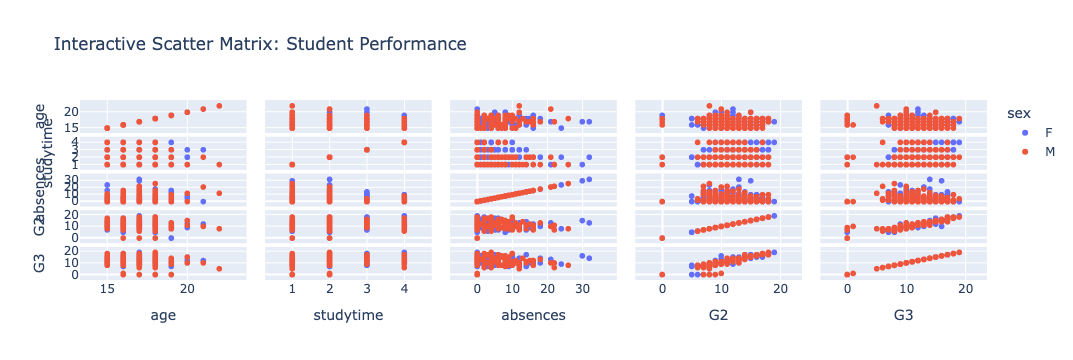

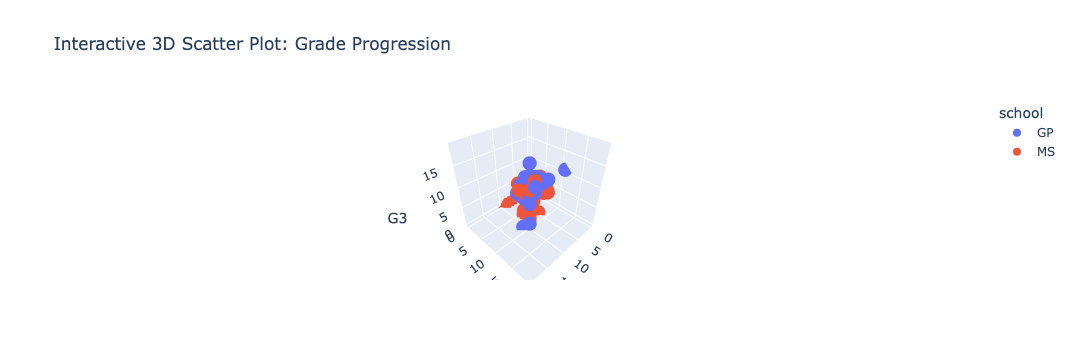

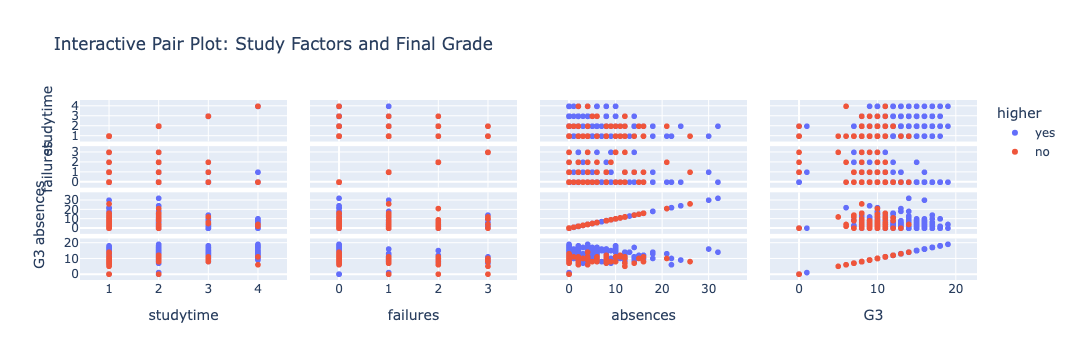

Saved: scatter_matrix.html, 3d_scatter.html, pair_plot.html


In [5]:
# Interactive scatter matrix
scatter_cols = ["age", "studytime", "absences", "G2", "G3"]

fig = px.scatter_matrix(
    df,
    dimensions=scatter_cols,
    color="sex",
    title="Interactive Scatter Matrix: Student Performance"
)
fig.write_html("reports/figures/scatter_matrix.html")
fig.show()

# Interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x="G1",
    y="G2",
    z="G3",
    color="school",
    hover_data=["sex", "age", "studytime", "absences"],
    title="Interactive 3D Scatter Plot: Grade Progression"
)
fig.write_html("reports/figures/3d_scatter.html")
fig.show()

# Interactive pair plot
pair_cols = ["studytime", "failures", "absences", "G3"]

fig = px.scatter_matrix(
    df,
    dimensions=pair_cols,
    color="higher",
    title="Interactive Pair Plot: Study Factors and Final Grade"
)
fig.write_html("reports/figures/pair_plot.html")
fig.show()

print("Saved: scatter_matrix.html, 3d_scatter.html, pair_plot.html")

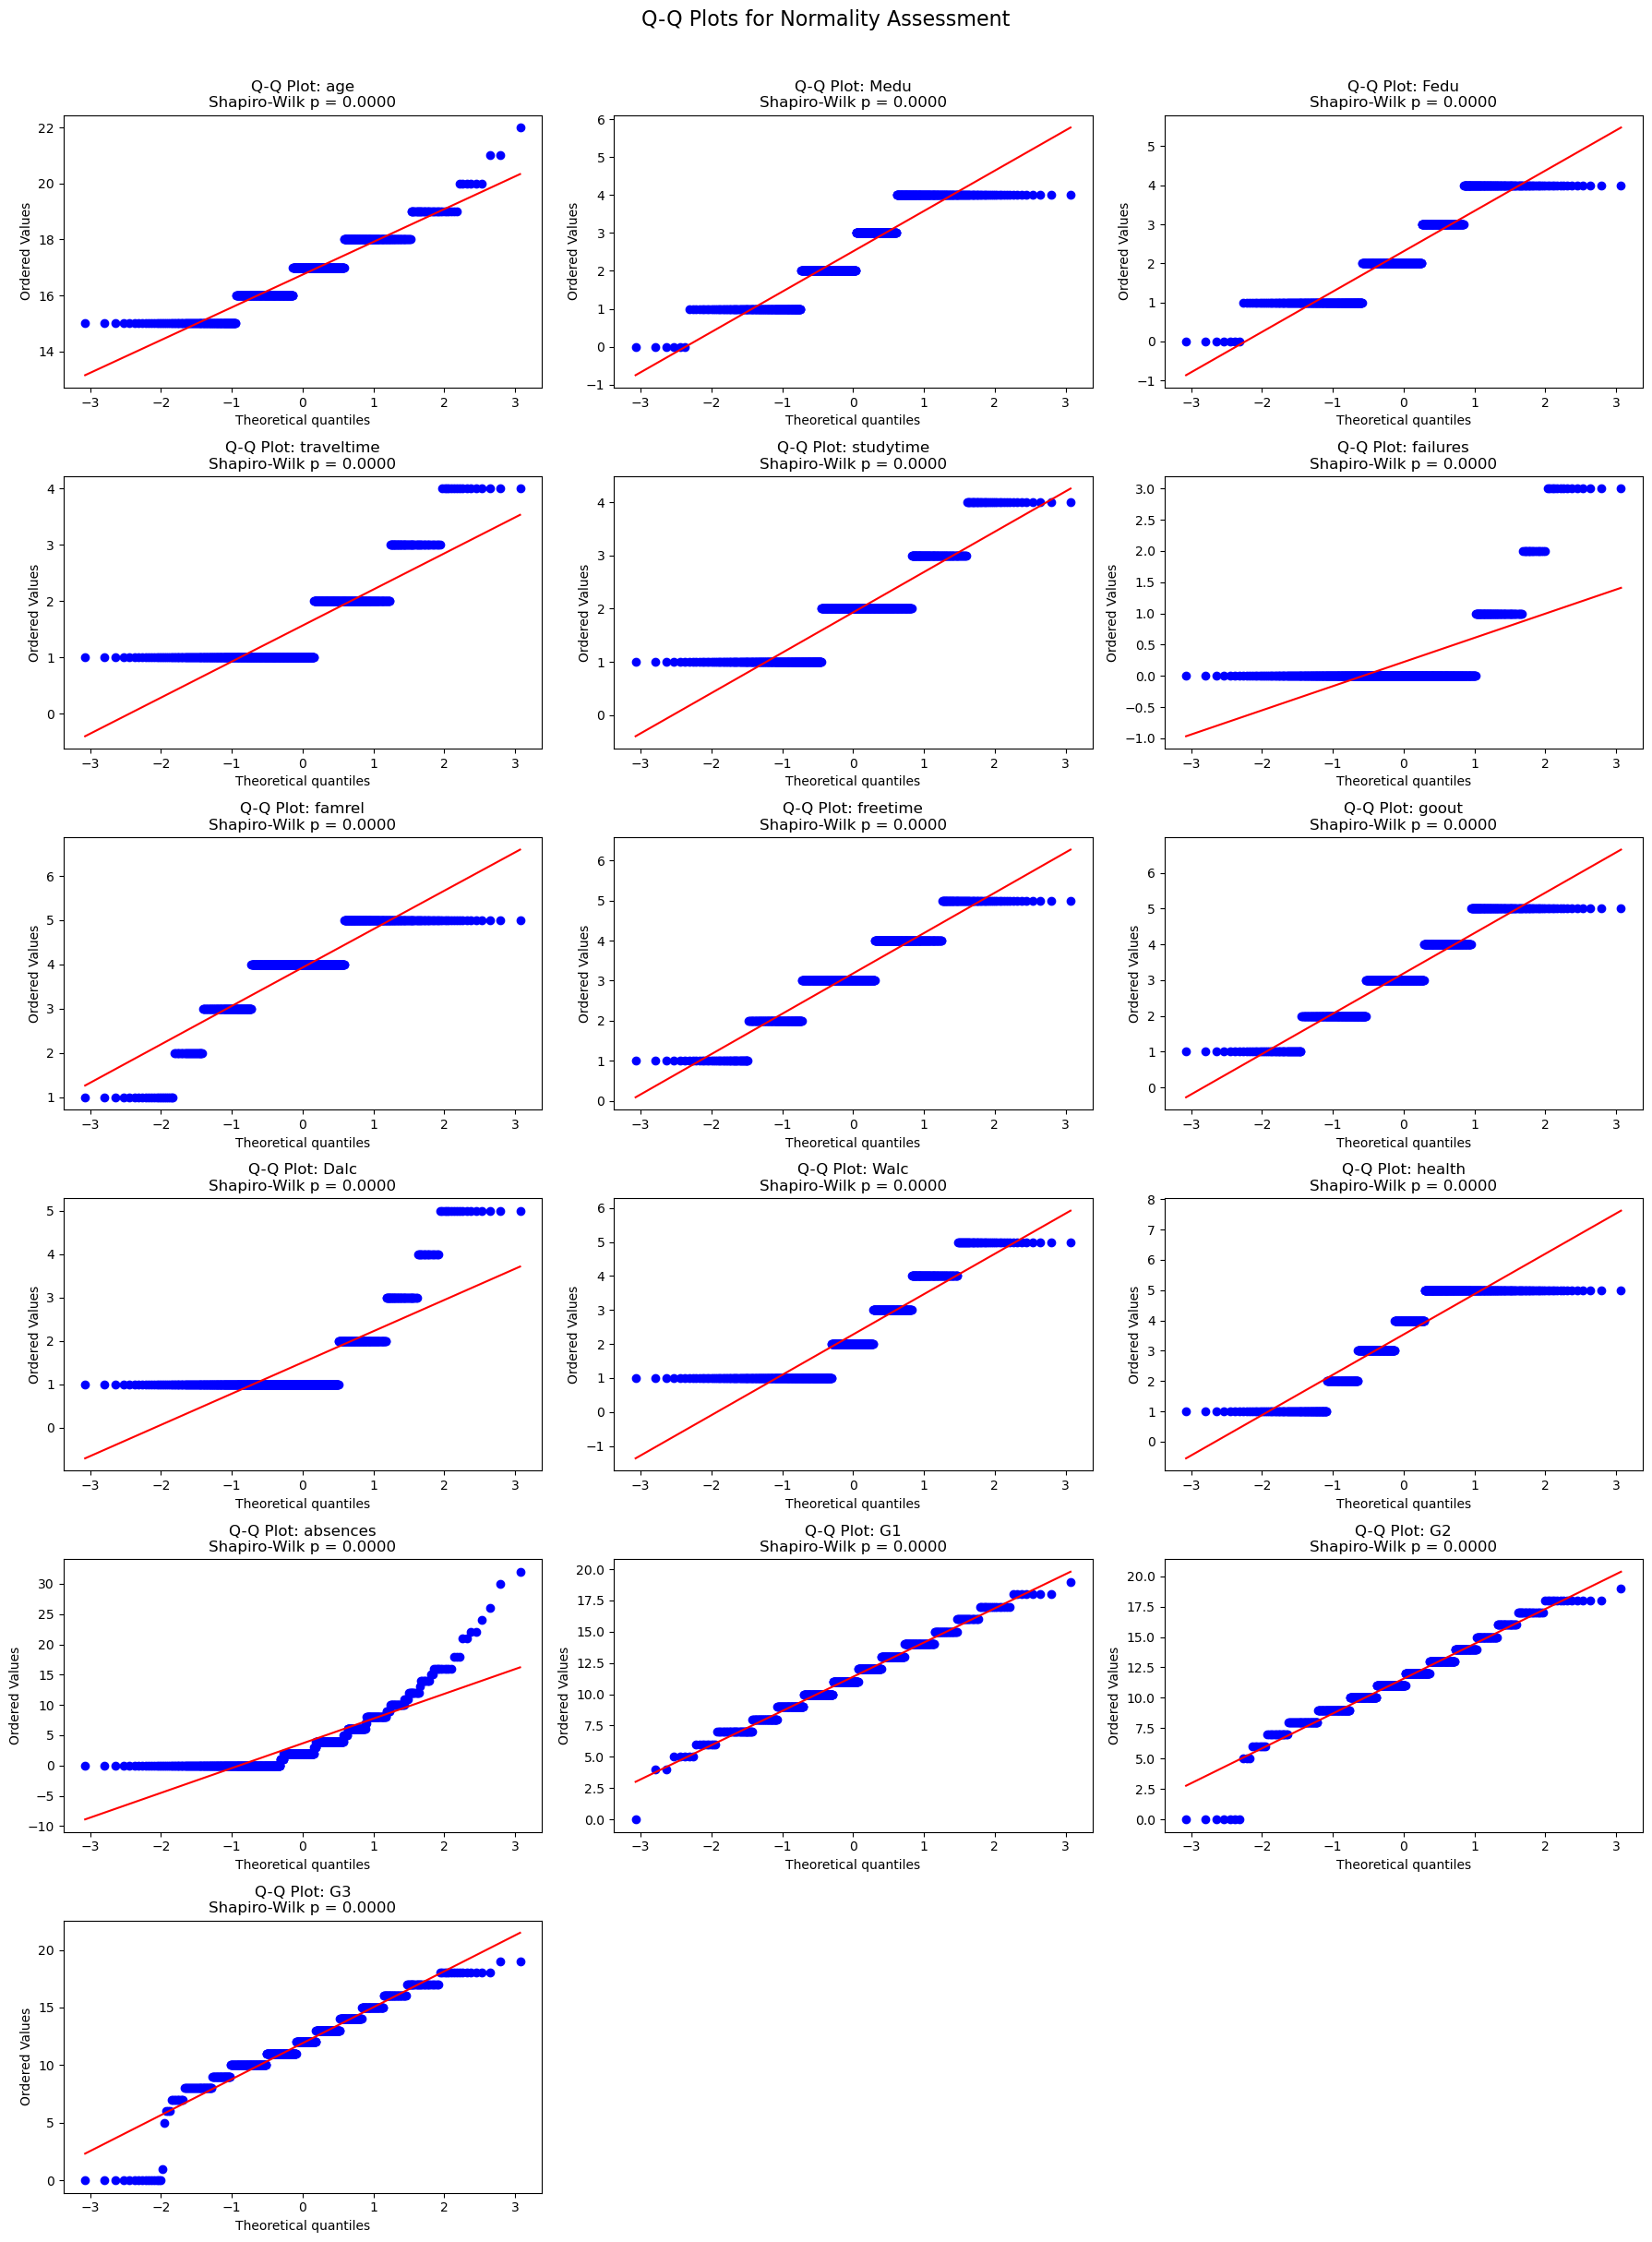

Saved: reports/figures/qq_plots.png


In [6]:
numeric_cols = df.select_dtypes(include="number").columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    values = df[col].dropna()

    stats.probplot(values, dist="norm", plot=ax)
    shapiro_stat, shapiro_p = stats.shapiro(values)

    ax.set_title(f"Q-Q Plot: {col}\nShapiro-Wilk p = {shapiro_p:.4f}")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Q-Q Plots for Normality Assessment", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("reports/figures/qq_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/qq_plots.png")

In [7]:
from pathlib import Path

expected_files = [
    "distribution_plots.png",
    "box_violin_plots.png",
    "correlation_heatmap.png",
    "qq_plots.png",
    "scatter_matrix.html",
    "3d_scatter.html",
    "pair_plot.html",
]

figures_dir = Path("reports/figures")
missing = []

for filename in expected_files:
    path = figures_dir / filename
    if path.exists():
        print(f"✓ {filename} ({path.stat().st_size:,} bytes)")
    else:
        missing.append(filename)
        print(f"✗ MISSING: {filename}")

assert not missing, f"Missing files: {missing}"
print("\nAll Student C visualization deliverables are saved.")

✓ distribution_plots.png (1,196,772 bytes)
✓ box_violin_plots.png (389,963 bytes)
✓ correlation_heatmap.png (752,800 bytes)
✓ qq_plots.png (1,124,440 bytes)
✓ scatter_matrix.html (4,777,238 bytes)
✓ 3d_scatter.html (4,783,902 bytes)
✓ pair_plot.html (4,776,255 bytes)

All Student C visualization deliverables are saved.
